**You are the average of the five people you spend the most time with.    - Jim Rohn**

The Quote: Suggests that an individual is shaped by the influences of the people closest to them.
k-NN Algorithm: Determines the class or value of a data point based on the characteristics of its closest neighbors in the feature space.
In both cases, proximity to a group influences the outcome:

In the quote, proximity is in terms of relationships or time spent.
In k-NN, proximity is in terms of Euclidean distance (or another metric) in a feature space.

In [166]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [127]:
df_original = pd.read_csv('Children Recode_final.csv')
columns = ['Underweight', 'Stunting', 'Wasting'] + [col for col in df_original.columns if col!= 'Wasting']
df1 = df_original[columns]
df1.head()

,Underweight,Stunting,Wasting,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,...,Religion_5,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10
0,0,0,0,17,1,14.0,0,1,2,22.00,...,0,1,0,0,0,0,0,0,0,0
1,0,1,0,40,2,17.0,1,2,2,25.10,...,0,0,0,0,0,0,0,1,0,0
2,0,1,0,59,2,17.0,1,2,2,25.10,...,0,0,0,0,0,0,0,1,0,0
3,1,1,0,55,2,17.0,0,2,2,21.53,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,14,1,16.0,0,1,2,28.03,...,0,0,0,0,0,0,0,1,0,0


## Stunting Prediction

In [128]:
df = df1.drop(['Underweight', 'Wasting'], axis = 1)
df.head()

,Stunting,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,...,Religion_5,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10
0,0,17,1,14.0,0,1,2,22.00,1,1,...,0,1,0,0,0,0,0,0,0,0
1,1,40,2,17.0,1,2,2,25.10,2,2,...,0,0,0,0,0,0,0,1,0,0
2,1,59,2,17.0,1,2,2,25.10,2,2,...,0,0,0,0,0,0,0,1,0,0
3,1,55,2,17.0,0,2,2,21.53,1,1,...,0,0,0,0,0,0,0,1,0,0
4,0,14,1,16.0,0,1,2,28.03,1,1,...,0,0,0,0,0,0,0,1,0,0


In [129]:
# Train Test Split

X = df.iloc[:,1:]
y = df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [136]:
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=19)

In [137]:
predictions = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)
accuracy

0.7790178571428571

In [132]:
columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [150]:
knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [165]:
predictions_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = knn_scaled.score(X_test_scaled, y_test)
print(f'Accuracy: {accuracy_scaled}')
confusion_matrix(y_test, predictions_scaled)

Accuracy: 0.8571428571428571


array([[332,  11],
       [ 53,  52]], dtype=int64)

### K-value for the best performance

In [ ]:
# Manual method
# k_range = range(1, 31)
# accuracy_scores = []

# # Peform cross-validation for each k
# for k in k_range:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     scores = cross_val_score(knn, X_train_scaled, y_train, cv = 5, scoring = 'accuracy') # 5 fold cross-validation
#     accuracy_scores.append(scores.mean())

# best_k = k_range[np.argmax(accuracy_scores)]
# print(f"Best k value: {best_k}")

Best k value: 11


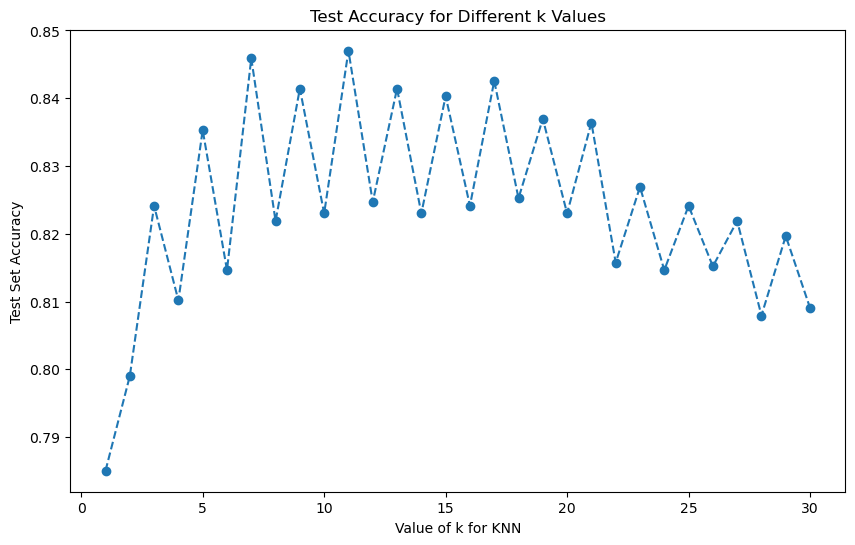

In [154]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# plt.plot(k_range, accuracy_scores, marker='o', linestyle='--')
# plt.xlabel('Value of k for KNN')
# plt.ylabel('Test Set Accuracy')
# plt.title('Test Accuracy for Different k Values')
# plt.show()

In [ ]:
# Using GridSearchCV

knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Define the grid of k values
param_grid = {'n_neighbors': range(1, 31)}

# Perform grid search with cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Best k value
print("Best k:", grid_search.best_params_['n_neighbors'])
print("Best accuracy:", grid_search.best_score_)


Best k: 11
Best accuracy: 0.847011406607429


Even thoufh best k value received is 11, the default k value works better for accuracy.

In [168]:
# Synthetic Minority Oversampling Technique (SMOTE)

y.value_counts()

Stunting
0    1660
1     579
Name: count, dtype: int64